In [1]:
# Install hypertools (dev-1.0 preview) -- run this first on Colab.
# On release this becomes: %pip install hypertools
import importlib.util
if importlib.util.find_spec('hypertools') is None:
    %pip install -q "hypertools[interactive] @ git+https://github.com/ContextLab/hypertools.git@dev-1.0"

# This tutorial also uses convokit + sentence-transformers (not HyperTools
# deps); self-install them so a top-to-bottom run works headlessly too.
if importlib.util.find_spec('convokit') is None:
    %pip install -q convokit
if importlib.util.find_spec('sentence_transformers') is None:
    %pip install -q sentence-transformers

# Visualizing the shape of a conversation

Conversations move.  A discussion drifts from topic to topic, doubles back on
itself, and takes sharp turns when a new speaker chimes in.  In this tutorial
we'll make that motion visible: we'll take a real Reddit conversation, embed a
sliding window of sentences within each utterance using a sentence-embedding
model, and use HyperTools to draw the conversation as a sequence of utterance
trajectories through meaning space -- colored by who is speaking, and animated
so that each utterance draws itself into the scene, one at a time.

This tutorial uses two extra libraries that are *not* installed with
HyperTools.  You can install them by running:

```
%pip install convokit sentence-transformers
```

(The animation step at the end also uses [ffmpeg](https://ffmpeg.org) to
convert the exported movie into a GIF.)

In [2]:
%matplotlib inline
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_HUB_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import warnings
warnings.filterwarnings('ignore')

import random
import re

import numpy as np

from convokit import Corpus, download
from sentence_transformers import SentenceTransformer

import hypertools as hyp

## Downloading a corpus of Reddit conversations

[ConvoKit](https://convokit.cornell.edu) provides easy access to dozens of
conversational datasets.  We'll use the `reddit-corpus-small` corpus, which
contains posts and comment threads sampled from 100 highly active
subreddits.

In [3]:
corpus = Corpus(filename=download('reddit-corpus-small'))
corpus.meta

Dataset already exists at /Users/jmanning/.convokit/saved-corpora/reddit-corpus-small


ConvoKitMeta({'subreddit': 'reddit-corpus-small', 'num_posts': 8286, 'num_comments': 288846, 'num_user': 119889})

## Choosing a conversation

We'll pick a conversation at random (seeded for reproducibility) from among
the conversations with at least 10 "usable" utterances -- i.e., utterances
whose text hasn't been deleted or removed.  Since we're about to trace how
individual utterances move through meaning space, we also require a
conversation where people actually say something: most utterances should
contain several sentences (at least 60% with 2+ sentence windows), with at
most 40 utterances so the animation stays legible.  Utterances are taken in
chronological order, treating the comment thread as one unfolding
conversation.

In [4]:
MIN_UTTERANCES = 10
MAX_UTTERANCES = 40
SENTENCE_WINDOW = 3

def usable_utterances(conversation):
    """Chronologically-ordered utterances with non-empty, non-deleted text."""
    utterances = conversation.get_chronological_utterance_list()
    return [u for u in utterances
            if u.text and u.text.strip()
            and u.text.strip() not in ('[deleted]', '[removed]')]

def split_sentences(text):
    """Simple sentence splitter: break on ., !, ? followed by whitespace."""
    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', text)]
    return [s for s in sentences if s]

def count_windows(text):
    sentences = split_sentences(text)
    return max(1, len(sentences) - SENTENCE_WINDOW + 1) \
        if len(sentences) >= SENTENCE_WINDOW else 1

def substantial(conversation):
    utterances = usable_utterances(conversation)
    if not MIN_UTTERANCES <= len(utterances) <= MAX_UTTERANCES:
        return False
    if len(set(u.speaker.id for u in utterances)) < 2:
        return False
    multi = sum(1 for u in utterances if count_windows(u.text.strip()) >= 2)
    return multi / len(utterances) >= 0.6

candidates = [c for c in corpus.iter_conversations() if substantial(c)]
print(f'qualifying conversations: {len(candidates)}')

random.seed(25)
conversation = random.choice(candidates)
utterances = usable_utterances(conversation)
speakers = [u.speaker.id for u in utterances]
texts = [u.text.strip() for u in utterances]

print(f"\ntitle: {conversation.meta['title']}")
print(f"subreddit: r/{conversation.meta['subreddit']}")
print(f'utterances: {len(utterances)}; speakers: {len(set(speakers))}')
print('\nopening exchange:')
for u in utterances[:4]:
    print(f'  [{u.speaker.id}] {u.text.strip()[:90]}...')

qualifying conversations: 244

title: Why don’t more cameras have dual native iso? Also, why couldn’t we have a sensor that captures images using multiple ISOs at once?
subreddit: r/photography
utterances: 10; speakers: 5

opening exchange:
  [CCtenor] We have all seen how good recent sensors are, capable of capturing almost 15 stops of dyna...
  [implode573] ISO doesn't work how you think it does. That "native ISO" you're looking for is called SNR...
  [CCtenor] Yes, and the “native iso” is the setting at which a camera is not applying any gain to the...
  [CCtenor] &gt; The SNR is there because heat and transferring. Many camera systems now work around t...


## Embedding each utterance with a sliding sentence window

To turn each utterance into its own mini-trajectory, we slide a window of 3
consecutive *sentences* along the text of that utterance, concatenate the
sentences inside each window, and embed each window with
[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
a compact sentence-BERT model.  Because the windows never cross utterance
boundaries, every utterance becomes a *truly separate* trajectory: utterances
never share points.

Utterances with fewer than 3 sentences get a single window containing the
whole utterance; single-window utterances have their embedding row duplicated
so that every utterance array has at least 2 rows.  (A duplicated point has
zero length as a line, so below we plot with the `'.-'` format -- dots at
every embedding window plus connecting lines -- which keeps single-window
utterances visible as single dots.)

In [5]:
utterance_windows = []   # list (per utterance) of lists of window texts
for text in texts:
    sentences = split_sentences(text)
    if len(sentences) < SENTENCE_WINDOW:
        windows = [text]  # one window: the whole utterance
    else:
        windows = [' '.join(sentences[i:i + SENTENCE_WINDOW])
                   for i in range(len(sentences) - SENTENCE_WINDOW + 1)]
    utterance_windows.append(windows)

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
flat_windows = [w for windows in utterance_windows for w in windows]
flat_embeddings = model.encode(flat_windows, show_progress_bar=False)

# carve the flat embedding matrix back into one array per utterance,
# duplicating the row for single-window utterances so each array has >= 2 rows
utterance_arrays, start = [], 0
for windows in utterance_windows:
    emb = flat_embeddings[start:start + len(windows)]
    start += len(windows)
    if emb.shape[0] == 1:
        emb = np.vstack([emb, emb])
    utterance_arrays.append(emb)

print(f'{len(utterance_arrays)} utterance trajectories; '
      f'windows per utterance: {[len(w) for w in utterance_windows]}')

10 utterance trajectories; windows per utterance: [31, 1, 1, 13, 11, 3, 6, 1, 17, 12]


## One color per speaker

Every speaker gets one fixed color, and every utterance is drawn in its
speaker's color -- so in a two-person conversation exactly two colors
alternate, and in this thread the colors repeat whenever a speaker takes
another turn.

We get that by handing `hyp.plot` a categorical `hue`: one speaker label per
embedding window.  HyperTools assigns each distinct label its own color from
seaborn's `hls` palette, in order of first appearance, and `legend=True`
gives each speaker exactly one legend entry.

In [6]:
# one hue label per embedding window; hypertools turns the distinct labels
# into one color per speaker (and, with legend=True, one legend entry each)
speaker_hue = [[speaker] * len(arr)
               for speaker, arr in zip(speakers, utterance_arrays)]

speaker_names = sorted(set(speakers), key=speakers.index)
print(f'{len(speaker_names)} speakers -> {len(speaker_names)} colors '
      f'across {len(utterance_arrays)} utterances')

5 speakers -> 5 colors across 10 utterances


## The static shape of the conversation

HyperTools reduces the 384-dimensional window embeddings to 3D and draws each
utterance as its own stroke, colored by its speaker.  The utterances are
*not* connected to each other -- each one is a separate trajectory through
meaning space.

`hyp.plot(utterance_arrays, '.-', ...)` stacks every utterance's windows into
one matrix, fits a *single* shared `IncrementalPCA` (the default `reduce`)
down to `ndims=3`, then splits the reduced rows back into per-utterance
trajectories.  Because one model is fit across all of them, positions are
directly comparable across utterances and across speakers.  The `'.-'` format
draws a dot at every embedding window plus lines connecting consecutive
windows *within* an utterance.

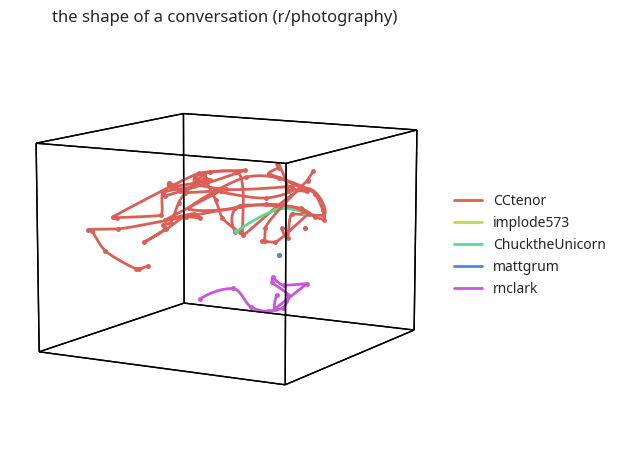

In [7]:
fig = hyp.plot(utterance_arrays, '.-', hue=speaker_hue, legend=True,
               linewidth=2, markersize=5, show=False,
               title=f"the shape of a conversation (r/{conversation.meta['subreddit']})")
fig

Each color is one speaker; each stroke is one utterance (utterances with a
single embedding window appear as a single dot).  Longer, winding
strokes are utterances that themselves wander across several ideas; compact
strokes are short, single-thought comments.

## Watching the conversation unfold

Now for the fun part.  HyperTools' `animate='serial'` mode plays the datasets
back *in list order*: the first utterance grows point-by-point into place;
then the second grows while the first stays fixed; and so on until the whole
conversation has assembled itself -- all while the camera slowly makes one
orbit of the scene over the 30-second animation.  Utterances are never
connected to each other; each new stroke simply appears where the
conversation went next.

`zoom=1.5` pulls the camera in so the trajectories fill more of the frame,
and `frame_rate=30` sets the rendered frames per second -- so `duration=30` x
`frame_rate=30` is 900 rendered frames, spread over the camera's
`rotations=1` single orbit.

We'll save the animation as an MP4 (compact and fast to render), then use
ffmpeg to convert it into a GIF for inline display.

In [8]:
fig, ani = hyp.plot(utterance_arrays, '.-', hue=speaker_hue,
               markersize=5,
               animate='serial', duration=30, rotations=1, frame_rate=30,
               zoom=1.5, linewidth=2,
               save_path='conversation_serial.mp4', show=False)

print(f"mp4: {os.path.getsize('conversation_serial.mp4')/1e6:0.1f} MB")

mp4: 7.6 MB


In [9]:
import shutil
import subprocess

if shutil.which('ffmpeg'):
    filters = ('fps=30,scale=420:-1:flags=lanczos,split [a][b]; '
               '[a] palettegen=max_colors=64 [p]; '
               '[b][p] paletteuse=dither=bayer:bayer_scale=3')
    subprocess.run(['ffmpeg', '-y', '-i', 'conversation_serial.mp4',
                    '-vf', filters, 'conversation_serial.gif'],
                   check=True, capture_output=True)
    os.remove('conversation_serial.mp4')
    print(f"gif: {os.path.getsize('conversation_serial.gif')/1e6:0.1f} MB")
else:
    print('ffmpeg not found -- skipping GIF conversion; the animation '
          'is saved as conversation_serial.mp4 instead.')

gif: 9.5 MB


![Animated conversation trajectory (serial draw-in)](conversation_serial.gif)

*(The animation above is loaded from `conversation_serial.gif`, written by the cell above; if your environment does not render it inline, open the file directly.)*

## Next steps

Try a longer conversation (raise `MIN_UTTERANCES`), a different sentence
window length, or another ConvoKit corpus entirely (`movie-corpus`,
`supreme-court-arguments`, ...).  You could also compare *several*
conversations at once by passing multiple trajectories to `hyp.plot`, or use
`hyp.align` to map different conversations into a shared space.